In [54]:
# baseline model

In [55]:
# Load data + filter countries (>20 samples)

In [56]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def load_data(address):
    df = pd.DataFrame(pd.read_csv(address))
    return df
df = load_data('data/cost-of-living_v2.csv')
min_samples = 20
valid_country_names = df['country'].value_counts()
valid_country_names = valid_country_names[valid_country_names >= min_samples].index
filtered_df = df[df['country'].isin(valid_country_names)]

In [57]:
#Add column name

In [58]:
feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer'
]
grocery_cols = [f'x{i}' for i in range(9, 27)]
identity_cols = ['city', 'country']

grocery_df = filtered_df[identity_cols + grocery_cols].copy()
grocery_cols_features = {f'x{i}': name for i, name in zip(range(9, 27), feature_names)}
grocery_df = grocery_df.rename(columns=grocery_cols_features)

In [59]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(grocery_df)

In [60]:
grocery_df_imputed = grocery_df.fillna(grocery_df.mean(numeric_only=True))
missing_values_series = count_the_missing_values_of_each_column(grocery_df_imputed)
print(missing_values_series)

city               0
country            0
Milk               0
Bread              0
Rice               0
Eggs               0
Local Cheese       0
Chicken Fillets    0
Beef Round         0
Apples             0
Banana             0
Oranges            0
Tomato             0
Potato             0
Onion              0
Lettuce            0
Water              0
Bottle of Wine     0
Domestic Beer      0
Imported Beer      0
dtype: int64


In [61]:
# Price index

In [62]:
usd_df = grocery_df_imputed.copy()
usd_df['Total_Basket'] = usd_df[feature_names].sum(axis=1)
usa_baseline = usd_df[usd_df['country'] == 'United States']['Total_Basket'].median()
usd_df['Grocery_Price_Index'] = usd_df['Total_Basket'] / usa_baseline
grocery_df_imputed['Grocery_Price_Index'] = usd_df['Grocery_Price_Index']
grocery_df_imputed.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,...,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer,Grocery_Price_Index
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,...,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36,1.514960
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,...,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97,0.855540
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,...,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26,0.639668
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,...,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61,0.477209
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,...,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49,0.430809


In [63]:
#Split x,y

In [64]:
grocery_items = feature_names # The 18 items
macro_signal = ['Grocery_Price_Index'] # Macro

X_macro = grocery_df_imputed[macro_signal]
X_fingerprint = grocery_df_imputed[grocery_items]
X_full = grocery_df_imputed[grocery_items + macro_signal]
y = grocery_df_imputed['country']

In [65]:
#Baseline model


===== Top Error Countries (Macro Only (Index)) =====
true
Algeria      1.0
Argentina    1.0
Australia    1.0
Belgium      1.0
Bulgaria     1.0
Canada       1.0
Chile        1.0
China        1.0
Greece       1.0
Colombia     1.0
Name: error, dtype: float64


--- Results for: Algeria using Macro Only (Index) ---
Countries Most Similar:
Brazil            4
India             2
United Kingdom    1
Name: count, dtype: int64


--- Results for: Argentina using Macro Only (Index) ---
Countries Most Similar:
India            2
United States    2
Brazil           1
Name: count, dtype: int64


--- Results for: Australia using Macro Only (Index) ---
Countries Most Similar:
United States    13
Name: count, dtype: int64


--- Results for: Belgium using Macro Only (Index) ---
Countries Most Similar:
United States    8
Name: count, dtype: int64


--- Results for: Bulgaria using Macro Only (Index) ---
Countries Most Similar:
Brazil    3
India     3
Name: count, dtype: int64


--- Results for: Canada us

<Figure size 800x600 with 0 Axes>

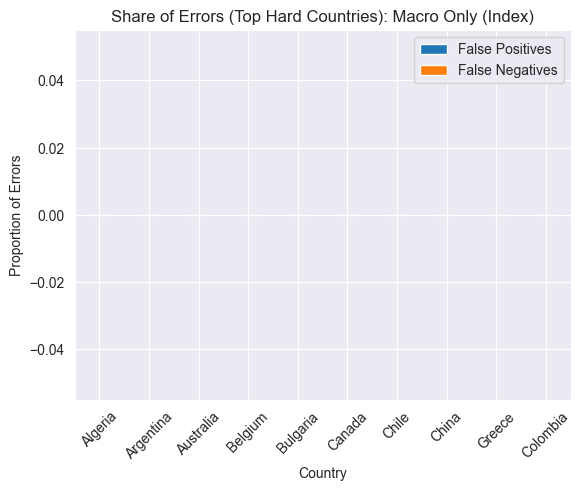


===== Top Error Countries (Full Model (Both)) =====
true
Belgium            1.000000
Chile              0.800000
North Macedonia    0.800000
Ireland            0.750000
Finland            0.600000
Argentina          0.600000
Slovenia           0.600000
Malta              0.571429
South Korea        0.500000
France             0.478261
Name: error, dtype: float64


--- Results for: Belgium using Full Model (Both) ---
Countries Most Similar:
France           5
Italy            2
United States    1
India            1
Germany          1
Name: count, dtype: int64


--- Results for: Chile using Full Model (Both) ---
Countries Most Similar:
Czech Republic    1
Brazil            1
Poland            1
South Africa      1
Portugal          1
Name: count, dtype: int64


--- Results for: North Macedonia using Full Model (Both) ---
Countries Most Similar:
Germany    1
Poland     1
Turkey     1
Romania    1
Italy      1
Name: count, dtype: int64


--- Results for: Ireland using Full Model (Both) --

<Figure size 800x600 with 0 Axes>

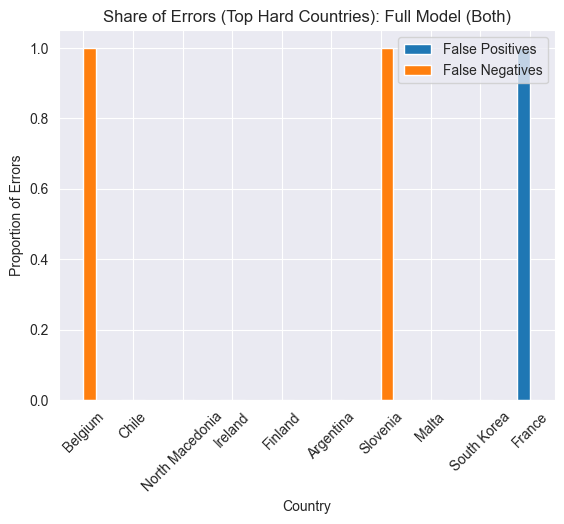

In [66]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

per_country_results = {}

feature_sets = {
    "Macro Only (Index)": X_macro,
    #"Fingerprint Only (Items)": X_fingerprint,
    "Full Model (Both)": X_full
}

for name, X_subset in feature_sets.items():

    # Split
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Train
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train_sub)
    y_pred = model.predict(X_test_scaled)


    # NEW: ERROR RATE SELECTION

    error_df = pd.DataFrame({
        'true': y_test_sub,
        'pred': y_pred
    })

    error_df['error'] = (error_df['true'] != error_df['pred'])

    error_rate = (
        error_df.groupby('true')['error']
        .mean()
        .sort_values(ascending=False)
    )

    top_countries = error_rate.head(10).index

    print(f"\n===== Top Error Countries ({name}) =====")
    print(error_rate.head(10))
    print("\n")


    # Confusion Pairs
    for country in top_countries:
        test = (y_test_sub == country)
        pred = (y_pred == country)

        falsePos = y_pred[test & (y_pred != country)]
        falseNeg = y_test_sub[pred & (y_test_sub != country)]

        print(f"--- Results for: {country} using {name} ---")
        print("Countries Most Similar:")

        combined = pd.concat([pd.Series(falsePos), pd.series(falseNeg)])
        print(combined.value_counts().head())

        print("\n")


    # Confusion Matrix (Top error countries)

    mask = y_test_sub.isin(top_countries)

    cm = confusion_matrix(
        y_test_sub[mask],
        y_pred[mask],
        labels=top_countries
    )


    # FP / FN analysis

    fps = []
    fns = []

    per_country_results[name] = {}

    for i, country in enumerate(top_countries):

        TP = cm[i][i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        TN = np.sum(cm) - TP - FP - FN

        per_country_results[name].update({
            f"{country} Accuracy": TP / (TP + FN) if (TP + FN) > 0 else 0,
            f"{country} Macro F1": f1_score(
                (y_test_sub == country),
                (y_pred == country),
                average='macro'
            ),
            f"{country} TP": TP,
            f"{country} FP": FP,
            f"{country} FN": FN,
            f"{country} TN": TN
        })

        total_errors = FP + FN
        if total_errors == 0:
            fps.append(0)
            fns.append(0)
        else:
            fps.append(FP / total_errors)
            fns.append(FN / total_errors)


    # Plot

    pltdf = pd.DataFrame({
        'False Positives': fps,
        'False Negatives': fns
    }, index=top_countries)

    plt.figure(figsize=(8, 6))
    ax = pltdf.plot.bar(rot=0)

    plt.xticks(rotation=45)
    ax.set_title(f"Share of Errors (Top Hard Countries): {name}")
    ax.set_ylabel('Proportion of Errors')
    ax.set_xlabel('Country')

    plt.show()